In [18]:
# Run this cell only if you need to install packages in your Jupyter environment.
# You can comment out the !pip lines if the packages are already installed.
!pip install -q geopandas pandas sqlalchemy pymysql folium contextily matplotlib pyyaml


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [19]:
# Imports + helper functions
# Updated helpers + plotting functions that label catchment 'name' and point 'grid_id'.
import re
from pathlib import Path
import yaml
import warnings

import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import contextily as ctx
import folium
from folium.plugins import MarkerCluster
from IPython.display import IFrame, display

FILE_REF_RE = re.compile(r"^\$\{file:(.+)\}$")

def load_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fh:
        return yaml.safe_load(fh)

def resolve_file_reference(value: str, config_dir: Path) -> str:
    if not isinstance(value, str):
        return value
    m = FILE_REF_RE.match(value.strip())
    if not m:
        return value
    ref = m.group(1).strip()
    ref_path = Path(ref)
    if not ref_path.is_absolute():
        ref_path = (config_dir / ref_path).resolve()
    if not ref_path.exists():
        raise FileNotFoundError(f"Referenced secret file not found: {ref_path}")
    with ref_path.open("r", encoding="utf-8") as f:
        content = f.read().strip()
    return content

def load_db_config(config_path: Path) -> dict:
    cfg = load_yaml(config_path)
    if "database" not in cfg or not isinstance(cfg["database"], dict):
        raise ValueError("Config file must contain a top-level 'database' mapping.")
    db = cfg["database"].copy()
    config_dir = config_path.parent
    if "password" in db:
        db["password"] = resolve_file_reference(db["password"], config_dir)
    return db

def get_db_engine_from_config(db_cfg: dict):
    host = db_cfg.get("host", "localhost")
    port = int(db_cfg.get("port", 3306))
    user = db_cfg["username"]
    password = db_cfg.get("password", "")
    dbname = db_cfg["database"]
    uri = f"mysql+pymysql://{user}:{password}@{host}:{port}/{dbname}?charset=utf8mb4"
    return create_engine(uri)

def read_grid_table(engine, model: str | None = None, limit: int | None = None) -> pd.DataFrame:
    where = ""
    params = {}
    if model:
        where = "WHERE model = %(model)s"
        params["model"] = model
    lim = f"LIMIT {int(limit)}" if limit else ""
    sql = f"SELECT grid_id, model, bbox_id, latitude, longitude, created_at FROM forecast_grid {where} {lim};"
    df = pd.read_sql_query(sql, engine, params=params)
    return df

def ensure_crs(gdf: gpd.GeoDataFrame, assumed_epsg: int = 4326) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        warnings.warn(f"Input GeoDataFrame has no CRS. Assuming EPSG:{assumed_epsg}.")
        return gdf.set_crs(epsg=assumed_epsg)
    return gdf

def make_static_map(catchments: gpd.GeoDataFrame, points: gpd.GeoDataFrame, out_path: Path = None,
                    catch_name_field: str = "name", point_label_field: str = "grid_id"):
    """
    Static Matplotlib map:
    - Annotates catchment centroid with the catch_name_field if present.
    - Annotates points with point_label_field (grid_id).
    """
    catch_web = ensure_crs(catchments).to_crs(epsg=3857)
    points_web = points.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 10))
    catch_web.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=0.6)
    points_web.plot(ax=ax, color="red", markersize=20, alpha=0.8, zorder=3)

    # Label points with grid_id (or provided field)
    if point_label_field in points_web.columns:
        for _, row in points_web.iterrows():
            lbl = row.get(point_label_field)
            if pd.notna(lbl):
                ax.annotate(str(lbl), xy=(row.geometry.x, row.geometry.y),
                            xytext=(4, 4), textcoords="offset points", fontsize=7, color="darkred", zorder=4)

    # Label catchments with name field at centroid (if field exists)
    if catch_name_field in catch_web.columns:
        # compute centroids (safe: use representative_point to ensure label inside polygon)
        centroids = catch_web.geometry.representative_point()
        for idx, geom in enumerate(centroids):
            name = catch_web.iloc[idx].get(catch_name_field)
            if pd.notna(name):
                ax.annotate(str(name), xy=(geom.x, geom.y),
                            xytext=(3, 3), textcoords="offset points", fontsize=8, color="black",
                            bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6), zorder=5)
    else:
        warnings.warn(f"Catchment name field '{catch_name_field}' not found in catchments. No catchment labels drawn.")

    try:
        ctx.add_basemap(ax, source=ctx.providers.Stamen.TerrainBackground)
    except Exception:
        pass

    ax.set_axis_off()
    plt.title("Catchments (names) and Grid Locations (grid_id)")
    plt.tight_layout()
    if out_path:
        fig.savefig(str(out_path), dpi=150)
        print(f"Saved static map to {out_path}")
    plt.show()
    plt.close(fig)

def make_interactive_map(catchments: gpd.GeoDataFrame, points: gpd.GeoDataFrame, out_html: Path = None,
                         catch_name_field: str = "name", point_label_field: str = "grid_id",
                         map_width=900, map_height=600):
    """
    Interactive folium map:
    - catchments GeoJson includes a tooltip showing catch_name_field (if present)
    - points show a popup with grid_id and optionally a tooltip with grid_id
    """
    catch_wgs = ensure_crs(catchments).to_crs(epsg=4326)

    # Map center: prefer points if available
    if len(points) > 0:
        center = [points.geometry.y.mean(), points.geometry.x.mean()]
    else:
        center_geom = catch_wgs.unary_union.centroid
        center = [center_geom.y, center_geom.x]
    m = folium.Map(location=center, zoom_start=8, tiles="OpenStreetMap")

    # Add catchments with tooltip for the name
    gj_kwargs = {}
    if catch_name_field in catch_wgs.columns:
        tooltip = folium.GeoJsonTooltip(fields=[catch_name_field], aliases=["Catchment:"])
        gj_kwargs["tooltip"] = tooltip
    else:
        warnings.warn(f"Catchment name field '{catch_name_field}' not found; GeoJson will not have name tooltip.")

    folium.GeoJson(
        catch_wgs.__geo_interface__,
        name="catchments",
        style_function=lambda feat: {
            "fillColor": "#ffff00",
            "color": "#444444",
            "weight": 1,
            "fillOpacity": 0.2,
        },
        **gj_kwargs
    ).add_to(m)

    # Add points with cluster; popup shows grid_id and other fields
    marker_cluster = MarkerCluster().add_to(m)
    for _, row in points.iterrows():
        grid_id = row.get(point_label_field)
        popup_parts = []
        popup_parts.append(f"grid_id: {grid_id}")
        # include model and bbox_id for context if present
        if "model" in row and pd.notna(row.get("model")):
            popup_parts.append(f"model: {row.get('model')}")
        if "bbox_id" in row and pd.notna(row.get("bbox_id")):
            popup_parts.append(f"bbox_id: {row.get('bbox_id')}")
        popup_html = "<br>".join(popup_parts)

        tooltip_text = f"grid_id: {grid_id}" if pd.notna(grid_id) else None

        folium.CircleMarker(
            location=(row['latitude'], row['longitude']),
            radius=5,
            color="red",
            fill=True,
            fill_opacity=0.9,
            popup=folium.Popup(popup_html, parse_html=True),
            tooltip=tooltip_text
        ).add_to(marker_cluster)

    if out_html:
        m.save(str(out_html))
        print(f"Saved interactive map to {out_html}")
        display(IFrame(src=str(out_html), width=map_width, height=map_height))
    else:
        display(m)

In [20]:
from pathlib import Path

# Paths - change to your actual files in the notebook filesystem
config_path = Path("db-config.yml")   # path to YAML shown above
shapefile_path = Path("./Subbasin_WGS84/Subbasin_WGS84.shp")  # path to your shapefile (.shp + .dbf + .shx etc)
out_static = Path("catchments_grid_map.png")
out_html = Path("catchments_grid_map.html")

# Load DB config (resolves ${file:...} references relative to config.yaml)
db_cfg = load_db_config(config_path)
# don't print password
print("DB host:", db_cfg.get("host"))
print("DB user:", db_cfg.get("username"))
print("DB name:", db_cfg.get("database"))

engine = get_db_engine_from_config({
    "host": db_cfg.get("host"),
    "port": db_cfg.get("port", 3306),
    "username": db_cfg.get("username"),
    "password": db_cfg.get("password"),
    "database": db_cfg.get("database"),
})
print("SQLAlchemy engine created.")

DB host: localhost
DB user: test
DB name: testdb
SQLAlchemy engine created.


In [21]:
# Optional: filter by model or limit rows for large datasets
model_filter = None   # e.g. "some_model_name" or None
limit_rows = None     # e.g. 1000 or None

df = read_grid_table(engine, model=model_filter, limit=limit_rows)
print("Rows fetched:", len(df))
df.head()

Rows fetched: 91


,grid_id,model,bbox_id,latitude,longitude,created_at
0,1,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.084540,2026-03-29 14:48:10
1,2,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.161400,2026-03-29 14:48:10
2,3,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.238260,2026-03-29 14:48:10
3,4,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.315120,2026-03-29 14:48:10
4,5,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.391975,2026-03-29 14:48:10


In [22]:
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)
print(gdf_points.crs)
gdf_points.head()

EPSG:4326


,grid_id,model,bbox_id,latitude,longitude,created_at,geometry
0,1,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.084540,2026-03-29 14:48:10,POINT (81.08454 7.97891)
1,2,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.161400,2026-03-29 14:48:10,POINT (81.1614 7.97891)
2,3,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.238260,2026-03-29 14:48:10,POINT (81.23826 7.97891)
3,4,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.315120,2026-03-29 14:48:10,POINT (81.31512 7.97891)
4,5,ecmwf_ifs,"7.28,81.1,7.98,81.8",7.97891,81.391975,2026-03-29 14:48:10,POINT (81.39198 7.97891)


In [23]:
catchments = gpd.read_file(str(shapefile_path))
catchments = ensure_crs(catchments)   # assumes EPSG:4326 if none set
print("Catchments CRS:", catchments.crs)
catchments.head()

Catchments CRS: EPSG:4326


,name,centroid_x,centroid_y,area_sqkm,latitude,longitude,basinid,geometry
0,S_Layan_Aru_Up,569128.474500,580108.277399,73.471742,81.398474,7.724480,6,"POLYGON ((81.3795 7.76478, 81.38172 7.76478, 8..."
1,S_Piburuththewa_Up,542545.037691,574478.748771,102.222045,81.157411,7.673856,7,"POLYGON ((81.17388 7.74277, 81.17471 7.74276, ..."
2,S_Kalugaloya_Res_Up,581209.652800,545336.047847,48.311695,81.507470,7.409868,18,"POLYGON ((81.52156 7.44991, 81.52267 7.44991, ..."
3,S_Mangalagama_Up,576036.517108,548974.222070,155.347114,81.460656,7.442842,20,"POLYGON ((81.48013 7.54178, 81.48207 7.54178, ..."
4,S_Unnichchai_Res_up,583100.156475,561294.279418,71.189344,81.524845,7.554146,38,"POLYGON ((81.54568 7.60483, 81.54651 7.60482, ..."


Saved static map to catchments_grid_map.png


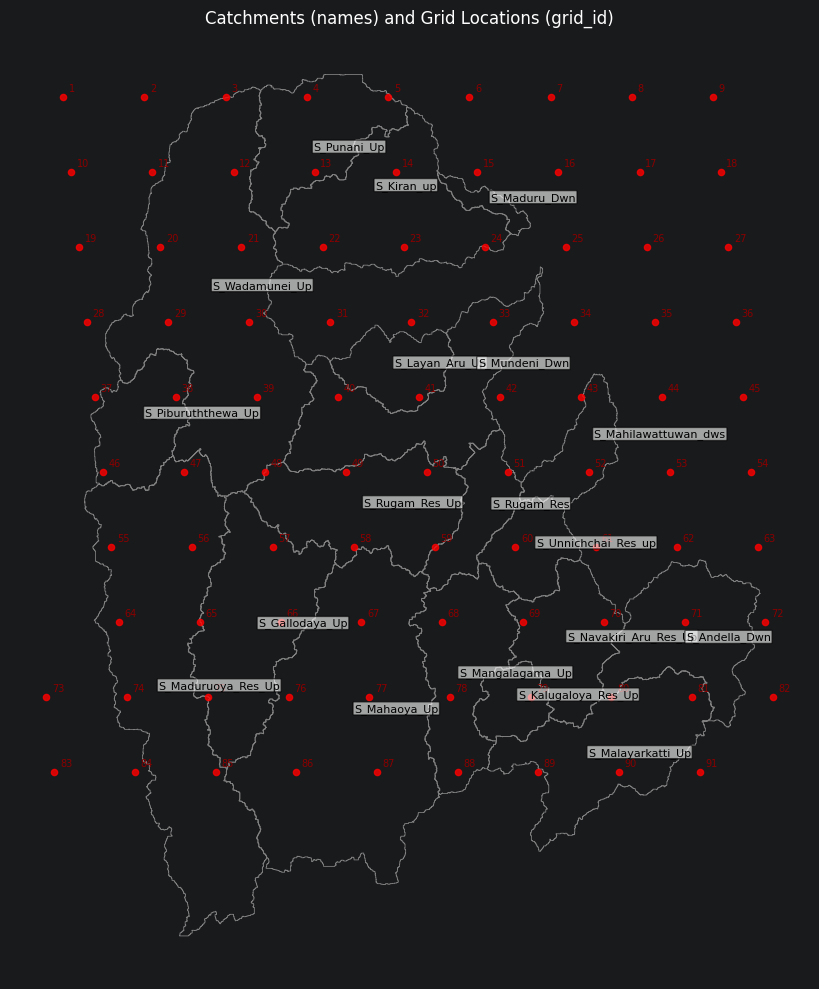

In [24]:
# Show inline static map; optionally save to out_static file
# Static map that labels catchment names and point grid_id
# Provide field names if your shapefile uses a different name column.
catchment_name_field = "name"    # change if your shapefile uses another attribute for the catchment name
point_id_field = "grid_id"

make_static_map(catchments, gdf_points, out_path=out_static, catch_name_field=catchment_name_field, point_label_field=point_id_field)

In [25]:
# This will save the interactive HTML and display it inline (IFrame).
# Interactive map that shows catchment names on hover and grid_id in marker popups
catchment_name_field = "name"    # change if necessary
point_id_field = "grid_id"

make_interactive_map(catchments, gdf_points, out_html=out_html, catch_name_field=catchment_name_field, point_label_field=point_id_field)

Saved interactive map to catchments_grid_map.html
